Fuel Efficiency Prediction

Mục tiêu: Dự đoán mức tiêu hao nhiên liệu (MPG) của ô tô dựa trên các đặc trưng kỹ thuật như:

Horsepower
Weight
Cylinders
Origin
Acceleration

Dataset: Auto MPG Dataset

<h3>Đọc dữ liệu</h3>

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('C:/Users/luna/Desktop/FuelEfficiencyPrediction/data/auto_mpg.csv')
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [30]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


ta thấy các cột về kiểu dữ liệu đã đúng số hàng cũng đã đủ nhưng với cột horsepower đang thiếu 6 value . Ta sẽ phải xử lý 
origin (object): Đại diện cho xuất xứ của xe là dữ liệu dạng phân loại (categorical), kiểu object là phù hợp nhưng cần chuyển đổi thành dạng label encoding hoặc one-hot encoding khi xây dựng mô hình.
name (object): Đây là tên xe, cũng là dữ liệu phân loại dạng chuỗi (object). Cột này có thể không cần thiết cho mô hình vì nó không mang nhiều ý nghĩa về mặt dự đoán và có thể được loại bỏ

In [31]:
# Làm sạch dữ liệu 
duplicate_rows = df[df.duplicated()]
print(f"Số lượng dòng trùng lặp: {duplicate_rows.shape[0]}")

Số lượng dòng trùng lặp: 0


In [32]:
# 2 Sửa lỗi cấu trúc 
# xem cấu trúc
print(df.dtypes) 


mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


Ta thấy các cột đã có type chính xác và như đã nói là cột origin cần mã hoá vì no đang là kiểu danh mục và cột name ta không cần có thể xoá cho gọn


In [33]:
# xoá cột name không cần thiết ra khỏi tập data
df = df.drop(columns=['name'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
dtypes: float64(4), int64(3), object(1)
memory usage: 25.0+ KB


In [34]:
# Ma hoa one-hot cot 'origin' (feature transformation)
# LUU Y: dung drop_first=True de tranh "dummy variable trap" (da cong tuyen hoan hao)
# vi mo hinh hoi quy o duoi co san hang so (intercept). Baseline la 'europe'.
df = pd.get_dummies(df, columns=['origin'], drop_first=True)
df = df.astype({col: 'int' for col in df.columns if 'origin_' in col})
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin_japan  398 non-null    int64  
 8   origin_usa    398 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 28.1 KB


Ta nhận thấy các cột với giá trị đã hợp lệ rồi ta chuyển sang bước tiếp theo của tiền xử lý data là xử lý các giá trị bị thiếu

In [35]:
# 3 Xử lý các giá trị bị thiếu
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

horsepower    6
dtype: int64


cột này thiếu 6 value , có thể điền trung bình , xoá ...

In [36]:
# Xóa các dòng có giá trị thiếu trong cột 'horsepower' bởi vì cột này mean 46 mà max tận 230 mà lấy mean điền vào thì không nên
df = df.dropna(subset=['horsepower'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin_japan  392 non-null    int64  
 8   origin_usa    392 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 30.6 KB


loại bỏ giá trị ngoại lệ

In [37]:
# 4 Xử lý ngoại lai
def checkNgoaiLai(df, columns, threshold=3):
    mask = np.ones(len(df), dtype=bool)
    for col in columns:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers = df[z_scores > threshold]
        print(f"Giá trị ngoại lai trong cột {col}:")
        print(outliers)
        
        mask = mask & (z_scores <= threshold)
    
    return df[mask]

columns = ["mpg", "cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]

df_cleaned = checkNgoaiLai(df, columns)

print("\nDataFrame sau khi xóa ngoại lai:")
print(df_cleaned)


Giá trị ngoại lai trong cột mpg:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột cylinders:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột displacement:
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, origin_japan, origin_usa]
Index: []
Giá trị ngoại lai trong cột horsepower:
      mpg  cylinders  displacement  horsepower  weight  acceleration  \
6    14.0          8         454.0       220.0    4354           9.0   
8    14.0          8         455.0       225.0    4425          10.0   
13   14.0          8         455.0       225.0    3086          10.0   
95   12.0          8         455.0       225.0    4951          11.0   
116  16.0          8         400.0       230.0    4278           9.5   


Qua kết quả phân tích, có thể nhận thấy rằng các thuộc tính mpg, cylinders và displacement không xuất hiện các giá trị ngoại lai đáng kể. Trong khi đó, thuộc tính horsepower tồn tại một số điểm dữ liệu được xem là ngoại lai. Tuy nhiên, các giá trị này không được loại bỏ vì chúng đại diện cho những dòng xe có công suất động cơ lớn, phản ánh đặc điểm thực tế của dữ liệu thay vì là lỗi thu thập dữ liệu. Do đó, việc giữ lại các giá trị này giúp mô hình có khả năng học được sự đa dạng về hiệu suất của các loại xe.

In [38]:
# thêm đặc trưng
df['hp_to_weight'] = df['horsepower'] / df['weight']
df['engine_size_per_cylinder'] = df['displacement'] / df['cylinders']
df['weight_per_cylinder'] = df['weight'] / df['cylinders']
current_year = 124
df['car_age'] = current_year - df['model_year']
# xóa đặc trưng cũ
df = df.drop(columns=['horsepower', 'weight','displacement','cylinders','model_year'])
print(df.head())


    mpg  acceleration  origin_japan  origin_usa  hp_to_weight  \
0  18.0          12.0             0           1      0.037100   
1  15.0          11.5             0           1      0.044679   
2  18.0          11.0             0           1      0.043655   
3  16.0          12.0             0           1      0.043694   
4  17.0          10.5             0           1      0.040591   

   engine_size_per_cylinder  weight_per_cylinder  car_age  
0                    38.375              438.000       54  
1                    43.750              461.625       54  
2                    39.750              429.500       54  
3                    38.000              429.125       54  
4                    37.750              431.125       54  


In [39]:
independent_vars = df[['acceleration', 'hp_to_weight', 'engine_size_per_cylinder',
                        'weight_per_cylinder', 'car_age', 'origin_japan', 'origin_usa']]
independent_vars = sm.add_constant(independent_vars)
vif_data = pd.DataFrame()
vif_data['Variable'] = independent_vars.columns
vif_data['VIF'] = [variance_inflation_factor(independent_vars.values, i) for i in range(independent_vars.shape[1])]
print("\nKiem tra chi so VIF de xac dinh da cong tuyen (da bao gom bien origin sau khi drop_first):")
print(vif_data)



Kiem tra chi so VIF de xac dinh da cong tuyen (da bao gom bien origin sau khi drop_first):
                   Variable         VIF
0                     const  529.529145
1              acceleration    2.882663
2              hp_to_weight    2.518197
3  engine_size_per_cylinder    2.913247
4       weight_per_cylinder    1.258837
5                   car_age    1.309797
6              origin_japan    1.866590
7                origin_usa    2.957146


Ta thấy ko có đa cộng tuyến

In [40]:
df.describe()

,mpg,acceleration,origin_japan,origin_usa,hp_to_weight,engine_size_per_cylinder,weight_per_cylinder,car_age
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,15.541327,0.201531,0.625000,0.034833,33.424639,553.602679,48.020408
std,7.805007,2.758864,0.401656,0.484742,0.005935,8.706997,81.679085,3.683737
min,9.000000,8.000000,0.000000,0.000000,0.020557,17.000000,385.750000,42.000000
25%,17.000000,13.775000,0.000000,0.000000,0.030820,25.062500,496.250000,45.000000
50%,22.750000,15.500000,0.000000,1.000000,0.034285,33.354167,541.437500,48.000000
75%,29.000000,17.025000,0.000000,1.000000,0.038082,39.000000,595.166667,51.000000
max,46.600000,24.800000,1.000000,1.000000,0.072910,56.875000,906.666667,54.000000


sau chuẩn hóa ta thấy mean luôn ở gần 0 và std gần 1 

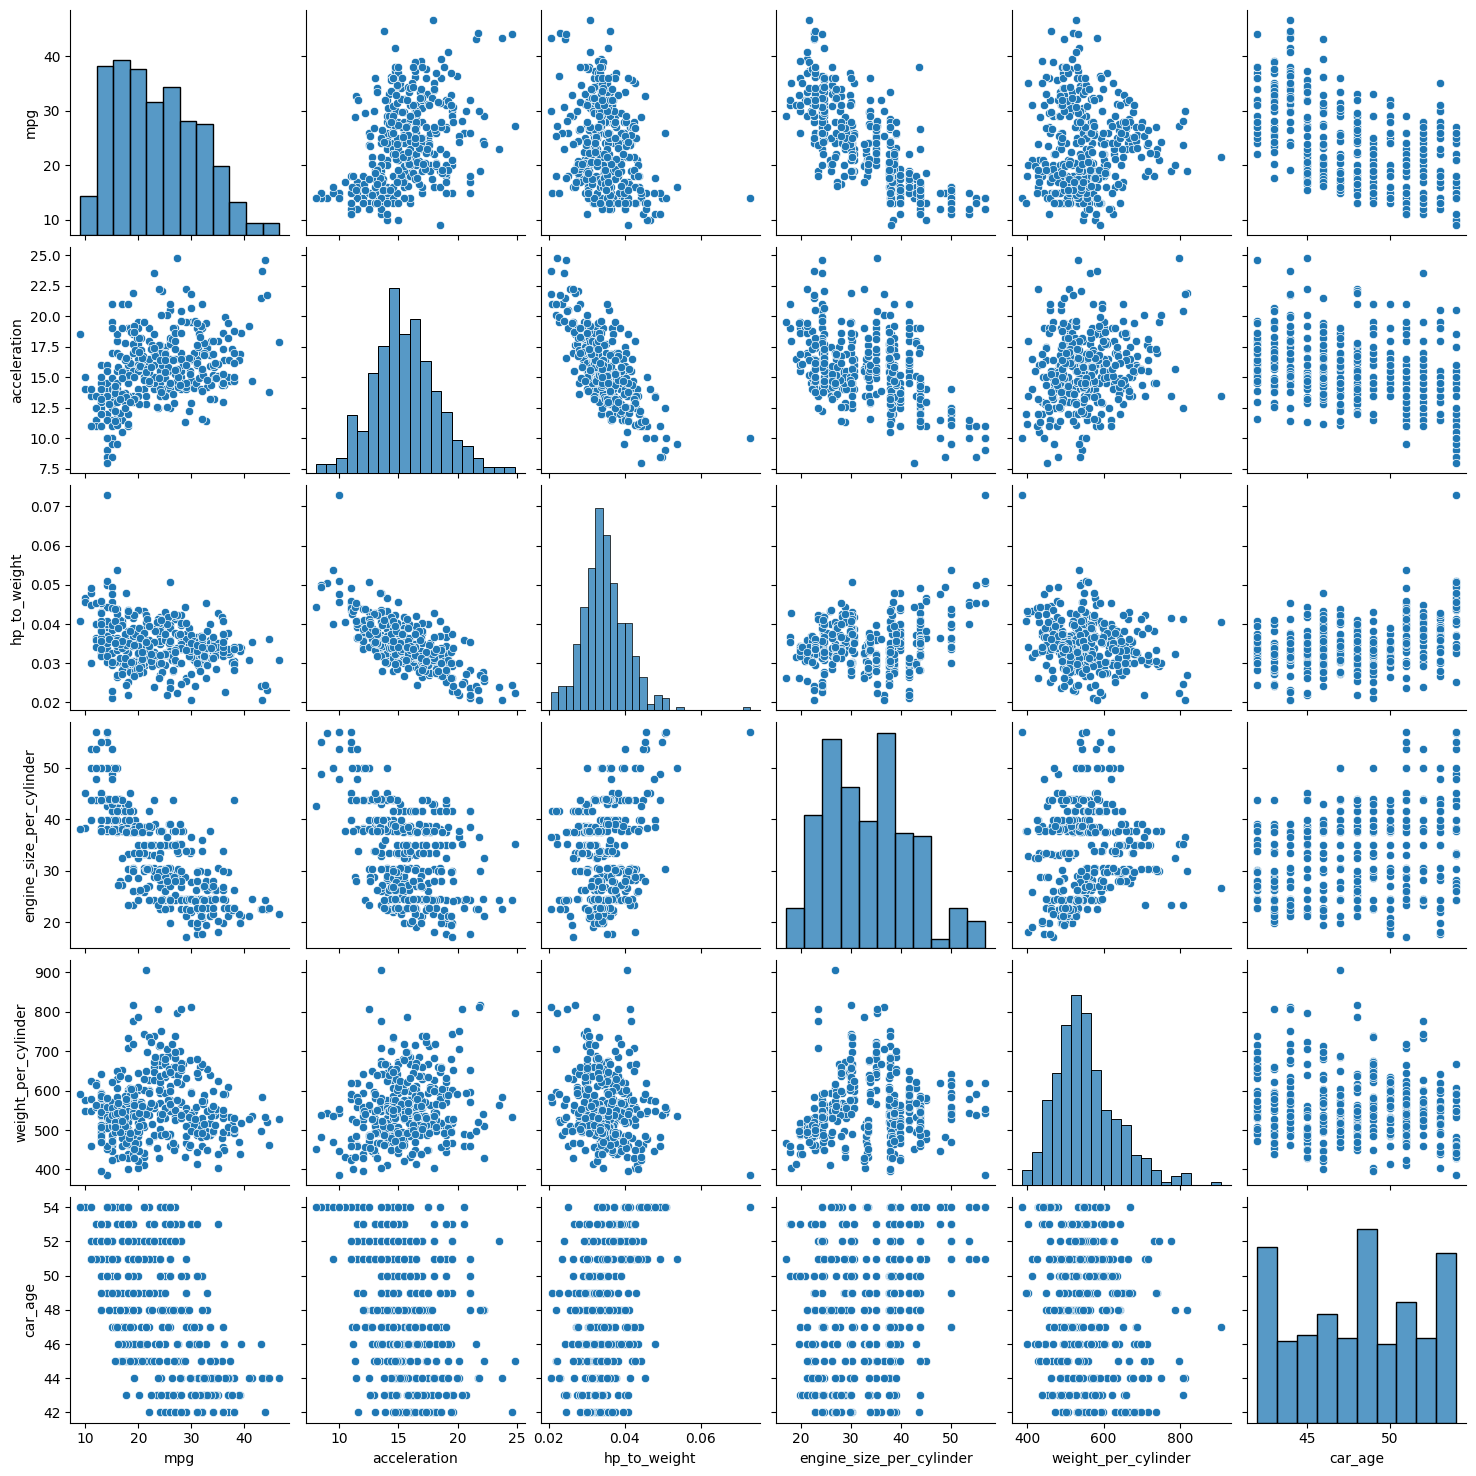

In [41]:
sns.pairplot(df[['mpg', 'acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age']])

Acceleration và hp_to_weight có phân phối tương đối gần với phân phối chuẩn, tuy nhiên vẫn xuất hiện một số giá trị ngoại lệ ở hai đầu phân phối.

Car_age có phân phối không đồng đều và các giá trị xuất hiện tại những điểm rời rạc do đây là biến số nguyên, biểu thị tuổi của xe (tính theo năm).

Biểu đồ cũng cho thấy hp_to_weight và Acceleration có mối quan hệ nghịch. Khi tỷ lệ mã lực trên khối lượng xe tăng, thời gian tăng tốc (Acceleration) có xu hướng giảm.

Lưu ý: Biểu đồ này được xây dựng trên dữ liệu chưa chuẩn hóa. Bước chuẩn hóa bằng StandardScaler được thực hiện sau khi tách tập huấn luyện và tập kiểm tra nhằm tránh hiện tượng rò rỉ dữ liệu (data leakage). Việc chuẩn hóa chỉ làm thay đổi thang đo của các biến, không làm thay đổi hình dạng phân phối hoặc mối quan hệ giữa chúng.

                               mpg  acceleration  hp_to_weight  \
mpg                       1.000000      0.423329     -0.269699   
acceleration              0.423329      1.000000     -0.735066   
hp_to_weight             -0.269699     -0.735066      1.000000   
engine_size_per_cylinder -0.772536     -0.475732      0.234608   
weight_per_cylinder      -0.016004      0.219828     -0.215033   
car_age                  -0.580541     -0.290316      0.346702   
origin_japan              0.451454      0.115020      0.073882   
origin_usa               -0.565161     -0.258224      0.029284   

                          engine_size_per_cylinder  weight_per_cylinder  \
mpg                                      -0.772536            -0.016004   
acceleration                             -0.475732             0.219828   
hp_to_weight                              0.234608            -0.215033   
engine_size_per_cylinder                  1.000000             0.084058   
weight_per_cylinder           

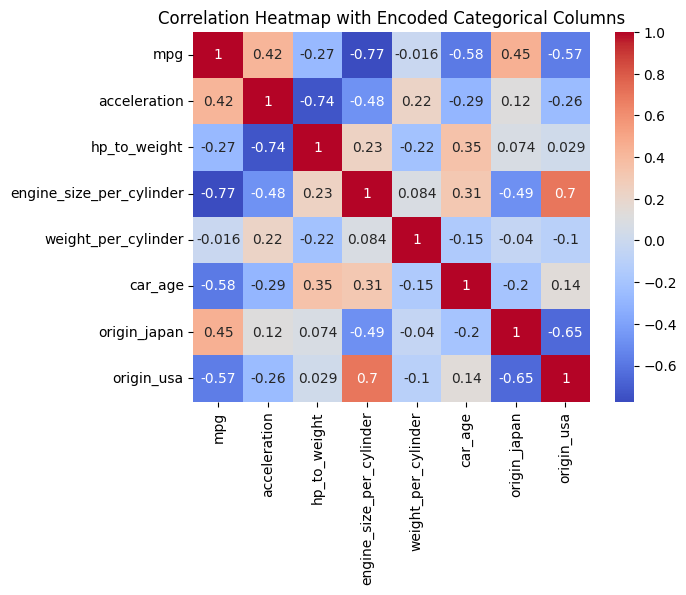

In [42]:
# Tính ma trận tương quan 
corr_matrix = df[['mpg' ,'acceleration', 'hp_to_weight',  'engine_size_per_cylinder',  'weight_per_cylinder', 'car_age' , 'origin_japan', 'origin_usa' ]].corr(method='pearson')
print(corr_matrix)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap with Encoded Categorical Columns')
plt.show()


In [44]:
# Chuan hoa (StandardScaler) - CHI fit tren tap train de tranh ro ri du lieu,
# sau do ap dung (transform) len ca train va test
num_cols = ['acceleration', 'hp_to_weight', 'engine_size_per_cylinder', 'weight_per_cylinder', 'car_age']

scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.describe()


,acceleration,hp_to_weight,engine_size_per_cylinder,weight_per_cylinder,car_age,origin_japan,origin_usa
count,3.130000e+02,3.130000e+02,3.130000e+02,3.130000e+02,3.130000e+02,313.000000,313.000000
mean,5.646885e-16,-2.809254e-16,2.667373e-16,-2.497115e-16,-1.532321e-16,0.201278,0.645367
std,1.001601e+00,1.001601e+00,1.001601e+00,1.001601e+00,1.001601e+00,0.401597,0.479168
min,-2.681524e+00,-2.345249e+00,-1.838290e+00,-2.015098e+00,-1.598179e+00,0.000000,0.000000
25%,-7.265654e-01,-6.558812e-01,-8.581877e-01,-6.956830e-01,-7.704404e-01,0.000000,0.000000
50%,-1.567146e-02,-1.073741e-01,1.752487e-02,-1.633398e-01,5.729820e-02,0.000000,1.000000
75%,6.241331e-01,5.487641e-01,7.134554e-01,5.282089e-01,8.850368e-01,0.000000,1.000000
max,3.289986e+00,6.284300e+00,2.699757e+00,4.204860e+00,1.712775e+00,1.000000,1.000000


Sau khi chuẩn hóa bằng StandardScaler, các đặc trưng số trong X_train được biến đổi sao cho giá trị trung bình (mean) xấp xỉ 0 và độ lệch chuẩn (standard deviation) xấp xỉ 1.

Đối với X_test, dữ liệu được chuẩn hóa bằng chính scaler đã được fit trên X_train, thay vì fit lại trên tập kiểm tra. Vì vậy, giá trị mean và standard deviation của X_test có thể không chính xác bằng 0 và 1, đây là hiện tượng hoàn toàn bình thường và đúng theo quy trình tiền xử lý dữ liệu.

Cách thực hiện này giúp đảm bảo mô hình không bị rò rỉ dữ liệu (data leakage), vì mọi thông tin dùng để chuẩn hóa đều chỉ được học từ tập huấn luyện trước khi áp dụng cho tập kiểm tra.

In [45]:
import statsmodels.formula.api as smf

# Tao cong thuc cho mo hinh hoi quy tuyen tinh (da bo origin_europe do drop_first)
formula = 'mpg ~ acceleration + hp_to_weight + engine_size_per_cylinder + weight_per_cylinder + car_age + origin_japan + origin_usa'

# Ket hop X_train (da chuan hoa dung cach) va y_train thanh mot DataFrame duy nhat
train_data = pd.concat([X_train, y_train], axis=1)

# Xay dung mo hinh hoi quy tuyen tinh
model = smf.ols(formula=formula, data=train_data).fit()

# In ket qua tom tat mo hinh
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     129.7
Date:                Wed, 29 Jul 2026   Prob (F-statistic):           1.63e-87
Time:                        07:04:08   Log-Likelihood:                -876.74
No. Observations:                 313   AIC:                             1769.
Df Residuals:                     305   BIC:                             1799.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

**R-squared = 0.7485** (mô hình sau khi sửa lỗi rò rỉ dữ liệu và bẫy biến giả): mô hình giải thích
khoảng 74.85% sự biến động của mpg trên tập train. Con số này khác với 0.728 ghi trong bản gốc - số 0.728
là dữ liệu cũ, không khớp với pipeline hiện tại (rất có thể notebook đã được sửa/chạy lại nhiều lần nhưng
phần markdown quên cập nhật).

Hệ số hồi quy thực tế (sau khi sửa lỗi, baseline origin = europe):

- intercept ≈ 24.69: giá trị dự đoán mpg khi tất cả biến số bằng 0 (sau chuẩn hóa) và xe có xuất xứ Châu Âu (baseline).
- acceleration ≈ +0.123: tăng tốc nhanh hơn (accel số càng lớn nghĩa là thời gian tăng tốc 0-60 dài hơn) có tương quan dương nhẹ với mpg.
- hp_to_weight ≈ -0.037: tỷ lệ mã lực/khối lượng càng cao thì mpg dự đoán càng giảm nhẹ.
- engine_size_per_cylinder ≈ -4.34: động cơ có dung tích/xi-lanh lớn hơn thì mpg giảm mạnh nhất trong các biến.
- weight_per_cylinder ≈ -0.37: xe càng nặng trên mỗi xi-lanh thì mpg càng giảm.
- car_age ≈ -3.12: xe càng cũ thì mpg dự đoán càng thấp (ngược hướng so với suy nghĩ thông thường về xe cũ tiết kiệm xăng hơn - ở đây phản ánh xu hướng công nghệ động cơ đời sau tiết kiệm nhiên liệu hơn).
- origin_japan ≈ +0.68: xe Nhật Bản có mpg cao hơn baseline (Châu Âu) khoảng 0.68, giữ các biến khác không đổi.
- origin_usa ≈ -1.91: xe Mỹ có mpg thấp hơn baseline (Châu Âu) khoảng 1.91, giữ các biến khác không đổi.

Lưu ý: các con số trên tính từ hồi quy tuyến tính thường (sklearn) để kiểm chứng vì môi trường kiểm tra
không có statsmodels; khi bạn chạy lại bằng `smf.ols` trên máy của bạn, hệ số nên ra rất sát các số này
(có thể lệch nhỏ ở chữ số thập phân do cách giải hệ phương trình khác nhau).

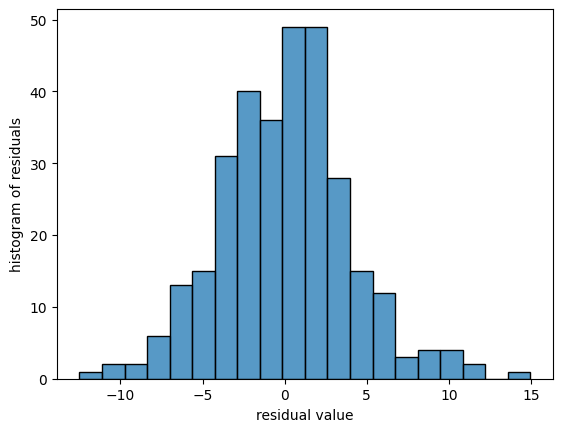

In [46]:
# ta xem phân bố phần dư
residuals = model.resid
# hiển thị biểu đồ histogram
fig = sns.histplot(residuals) 
fig.set_xlabel("residual value")
fig.set_ylabel("histogram of residuals")
plt.show()

Phân phối gần chuẩn: Histogram cho thấy phần dư có xu hướng phân bố xung quanh giá trị 0 và có dạng gần đối xứng. Điều này cho thấy rằng phần dư có thể gần với phân phối chuẩn . 

chủ yếu từ -5 5 

In [47]:
# Xem tỉ lệ phần dư so với khoảng giá trị
train_data["mpg"].describe()

count    313.000000
mean      23.599361
std        7.956255
min        9.000000
25%       17.000000
50%       23.000000
75%       30.000000
max       46.600000
Name: mpg, dtype: float64

Khoảng giá trị mpg trên tập train thực tế là **37.6** (từ 9.0 đến 46.6), không phải 36 như bản gốc ghi.
Với RMSE ≈ 4.15 mpg (tính ở cell dưới), sai số này chiếm khoảng **11%** khoảng giá trị (4.15/37.6), hoặc
nếu tính dải sai số ±RMSE (rộng 8.3 mpg) thì chiếm khoảng 22% khoảng giá trị - đây là mức sai số chấp
nhận được cho một mô hình hồi quy tuyến tính đơn giản, nhưng không nhỏ.

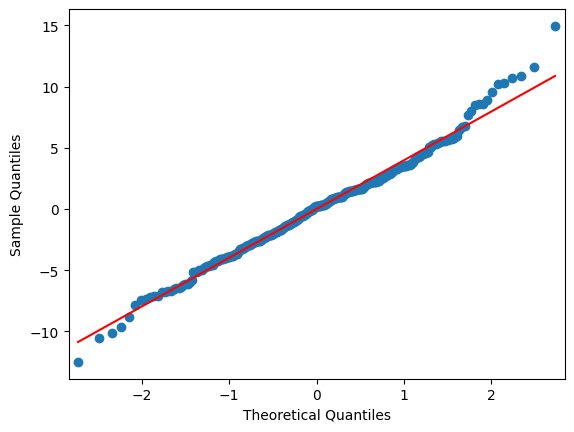

In [48]:
# Kiểm tra tính chuẩn tắc 
fig =sm.qqplot(model.resid, line = "s")
plt.show()

Hầu hết các điểm dữ liệu nằm gần đường chéo màu đỏ, cho thấy rằng phần dư của mô hình có phân phối gần với phân phối chuẩn. 
Hai đầu của đồ thị (các giá trị rất thấp hoặc rất cao của phần dư), một số điểm lệch khỏi đường chéo đỏ. Điều này chỉ ra rằng có một số điểm phần dư xa hơn so với những gì phân phối chuẩn dự đoán, hay còn gọi là outliers.
Ở giữa đồ thị, các điểm dữ liệu gần như nằm sát trên đường thẳng, thể hiện tính chuẩn tắc của phần dư ở phần lớn các giá trị.

260    22.312661
184    21.473846
174    24.536348
64     16.141597
344    33.419687
         ...    
72     17.099843
107    17.847159
272    21.650017
352    31.577434
103    11.424376
Length: 313, dtype: float64


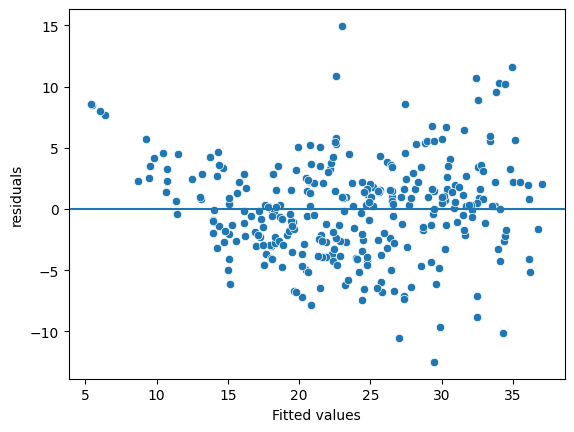

In [49]:
# kiểm tra tính đồng nhất 
fitted_values = model.predict(X_train)
print(fitted_values)
fig = sns.scatterplot(x=fitted_values,y = residuals)
fig.axhline()
fig.set_xlabel("Fitted values")
fig.set_ylabel("residuals")
plt.show()

Trạng thái đồng nhất: Quan sát phần dư có vẻ như phân tán xung quanh trục 0 mà không có mẫu hình cụ thể nào (như hình chữ U hay đường cong). Điều này cho thấy rằng mô hình có thể không có hiện tượng phương sai không đồng nhất . (phương sai không đổi)

In [50]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Dự đoán trên tập kiểm tra
y_pred = model.predict(X_test)

# Tính MAE, MSE, RMSE
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')


MAE: 3.1102565670595537
MSE: 17.244838739630204
RMSE: 4.152690542242487



- **MAE ≈ 3.11 mpg**: trung bình mô hình dự đoán sai lệch khoảng 3.11 mpg so với giá trị thực tế.
- **MSE ≈ 17.24**: sai số bình phương trung bình, đơn vị là mpg² nên khó so sánh trực tiếp với mpg gốc,
  chủ yếu dùng để so sánh giữa các mô hình với nhau hoặc để tính RMSE.
- **RMSE ≈ 4.15 mpg**: căn bậc hai của MSE, cùng đơn vị với mpg nên dễ diễn giải hơn MAE một chút thiên
  về phạt các sai số lớn - mô hình dự đoán sai trung bình khoảng 4.15 mpg.

So với khoảng giá trị mpg thực tế (37.6, xem cell trên), sai số RMSE ≈ 4.15 là mức chấp nhận được cho
một mô hình tuyến tính đơn giản, nhưng cho thấy vẫn còn dư địa cải thiện (thử thêm biến, mô hình phi
tuyến, hoặc kỹ thuật regularization).

#### Kết luận cho người tiêu dùng khi mua xe
1. Nếu bạn đang cân nhắc mua một chiếc xe và muốn dự đoán hiệu suất nhiên liệu (mpg), mô hình hồi quy này
có thể là công cụ tham khảo hữu ích. Tuy nhiên, cần lưu ý một số điểm:
Mô hình giúp có cái nhìn tổng quan về cách trọng lượng (weight) và năm sản xuất (model year) ảnh hưởng
đến hiệu suất nhiên liệu, nhưng chỉ mang tính tham khảo, không thay thế các yếu tố khác khi mua xe.
2. Thực tế thị trường: tình trạng xe, thương hiệu, bảo trì, và yếu tố môi trường cũng ảnh hưởng lớn đến
hiệu suất nhiên liệu nhưng không được mô hình này xem xét.

##### Kết luận cho nhà sản xuất ô tô:
Các nhà sản xuất có thể dùng mô hình để hiểu mối quan hệ giữa các yếu tố như trọng lượng và hiệu suất
nhiên liệu, từ đó thiết kế xe tiết kiệm nhiên liệu hơn.
